In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [6]:

dataset1 = pd.read_csv('/content/dataset.csv')
X = dataset1[['Size']].values
y = dataset1[['Price']].values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [8]:

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_scaler = MinMaxScaler()
y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)

In [9]:

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [10]:
# Name:SELVARANI S
# Register Number:212224040301
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 8)
        self.fc2 = nn.Linear(8, 10)
        self.fc3 = nn.Linear(10, 1)
        self.relu = nn.ReLU()
        self.history = {'loss': []}

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [11]:
selva_brain = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.RMSprop(selva_brain.parameters(), lr=0.001)

In [14]:

# Name:SELVARANI S
# Register Number:212224040301
def train_model(selva_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = criterion(selva_brain(X_train), y_train)
        loss.backward()
        optimizer.step()

        selva_brain.history['loss'].append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')

In [15]:
train_model(selva_brain, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 0.097216
Epoch [200/2000], Loss: 0.000278
Epoch [400/2000], Loss: 0.000113
Epoch [600/2000], Loss: 0.000032
Epoch [800/2000], Loss: 0.000032
Epoch [1000/2000], Loss: 0.000031
Epoch [1200/2000], Loss: 0.000039
Epoch [1400/2000], Loss: 0.000058
Epoch [1600/2000], Loss: 0.000008
Epoch [1800/2000], Loss: 0.000023


In [16]:
loss_df = pd.DataFrame(selva_brain.history)

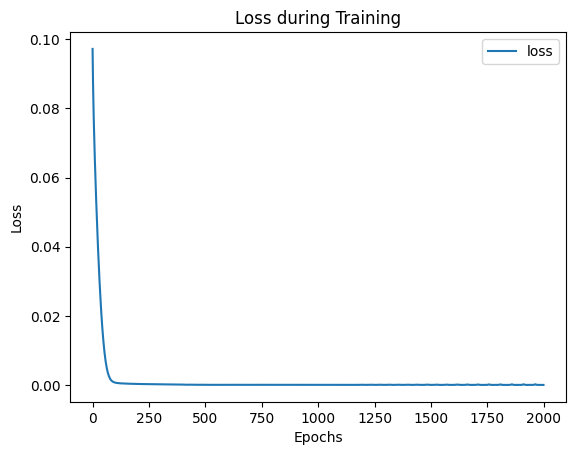

In [17]:

import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [29]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
scaled_input = scaler.transform(X_n1_1)

prediction_scaled = selva_brain(
    torch.tensor(scaled_input, dtype=torch.float32)
).detach().numpy()
prediction = y_scaler.inverse_transform(prediction_scaled)

print("Prediction:", prediction[0][0])

Prediction: 24.813442
